In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
from scipy.signal import find_peaks
import yfinance as yf

## data aand data cleaning

In [36]:
ticker = "MSFT"

In [37]:
# downloading the data
data = yf.download(
    ticker,
    start="2025-08-30",
    end="2026-08-30",
    interval="1d",
    auto_adjust=False,
    actions=True
)

[*********************100%***********************]  1 of 1 completed


In [38]:
data.head()

Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,,,,
2025-09-02,500.997925,505.119995,0.0,506.000000,496.809998,500.470001,0.0,18128000
2025-09-03,501.226074,505.350006,0.0,507.790009,502.320007,503.790009,0.0,16345100
2025-09-04,503.824738,507.970001,0.0,508.149994,503.149994,504.299988,0.0,15509500
2025-09-05,490.960571,495.000000,0.0,511.970001,492.369995,509.070007,0.0,31994800
2025-09-08,494.134430,498.200012,0.0,501.200012,495.029999,498.109985,0.0,16771000


In [39]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 250 entries, 2025-09-02 to 2026-08-28
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Adj Close, MSFT)     250 non-null    float64
 1   (Close, MSFT)         250 non-null    float64
 2   (Dividends, MSFT)     250 non-null    float64
 3   (High, MSFT)          250 non-null    float64
 4   (Low, MSFT)           250 non-null    float64
 5   (Open, MSFT)          250 non-null    float64
 6   (Stock Splits, MSFT)  250 non-null    float64
 7   (Volume, MSFT)        250 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 17.6 KB


In [40]:
data.head()

Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,,,,
2025-09-02,500.997925,505.119995,0.0,506.000000,496.809998,500.470001,0.0,18128000
2025-09-03,501.226074,505.350006,0.0,507.790009,502.320007,503.790009,0.0,16345100
2025-09-04,503.824738,507.970001,0.0,508.149994,503.149994,504.299988,0.0,15509500
2025-09-05,490.960571,495.000000,0.0,511.970001,492.369995,509.070007,0.0,31994800
2025-09-08,494.134430,498.200012,0.0,501.200012,495.029999,498.109985,0.0,16771000


In [41]:
# flattening
data.columns = data.columns.get_level_values(0)

In [42]:
data.head()

Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,
2025-09-02,500.997925,505.119995,0.0,506.000000,496.809998,500.470001,0.0,18128000
2025-09-03,501.226074,505.350006,0.0,507.790009,502.320007,503.790009,0.0,16345100
2025-09-04,503.824738,507.970001,0.0,508.149994,503.149994,504.299988,0.0,15509500
2025-09-05,490.960571,495.000000,0.0,511.970001,492.369995,509.070007,0.0,31994800
2025-09-08,494.134430,498.200012,0.0,501.200012,495.029999,498.109985,0.0,16771000


In [43]:
print(data.columns)
print(data.index.name)
print(data.dtypes)

Index(['Adj Close', 'Close', 'Dividends', 'High', 'Low', 'Open',
       'Stock Splits', 'Volume'],
      dtype='str', name='Price')
Date
Price
Adj Close       float64
Close           float64
Dividends       float64
High            float64
Low             float64
Open            float64
Stock Splits    float64
Volume            int64
dtype: object


In [44]:
data.columns.name = None

In [45]:
data.head()

,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,
2025-09-02,500.997925,505.119995,0.0,506.000000,496.809998,500.470001,0.0,18128000
2025-09-03,501.226074,505.350006,0.0,507.790009,502.320007,503.790009,0.0,16345100
2025-09-04,503.824738,507.970001,0.0,508.149994,503.149994,504.299988,0.0,15509500
2025-09-05,490.960571,495.000000,0.0,511.970001,492.369995,509.070007,0.0,31994800
2025-09-08,494.134430,498.200012,0.0,501.200012,495.029999,498.109985,0.0,16771000


In [46]:
data = data.reset_index()

In [47]:
data.head()

,Date,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
0,2025-09-02,500.997925,505.119995,0.0,506.000000,496.809998,500.470001,0.0,18128000
1,2025-09-03,501.226074,505.350006,0.0,507.790009,502.320007,503.790009,0.0,16345100
2,2025-09-04,503.824738,507.970001,0.0,508.149994,503.149994,504.299988,0.0,15509500
3,2025-09-05,490.960571,495.000000,0.0,511.970001,492.369995,509.070007,0.0,31994800
4,2025-09-08,494.134430,498.200012,0.0,501.200012,495.029999,498.109985,0.0,16771000


In [48]:
data.to_csv("../data/raw/MSFT.csv")

In [49]:
# checking for null values or dups
data.isnull().sum()

Date            0
Adj Close       0
Close           0
Dividends       0
High            0
Low             0
Open            0
Stock Splits    0
Volume          0
dtype: int64

In [50]:
data.duplicated().sum()

np.int64(0)

In [51]:
data.head()

,Date,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
0,2025-09-02,500.997925,505.119995,0.0,506.000000,496.809998,500.470001,0.0,18128000
1,2025-09-03,501.226074,505.350006,0.0,507.790009,502.320007,503.790009,0.0,16345100
2,2025-09-04,503.824738,507.970001,0.0,508.149994,503.149994,504.299988,0.0,15509500
3,2025-09-05,490.960571,495.000000,0.0,511.970001,492.369995,509.070007,0.0,31994800
4,2025-09-08,494.134430,498.200012,0.0,501.200012,495.029999,498.109985,0.0,16771000


## visualization and indicators

In [52]:
print(data.head())

        Date   Adj Close       Close  Dividends        High         Low  \
0 2025-09-02  500.997925  505.119995        0.0  506.000000  496.809998   
1 2025-09-03  501.226074  505.350006        0.0  507.790009  502.320007   
2 2025-09-04  503.824738  507.970001        0.0  508.149994  503.149994   
3 2025-09-05  490.960571  495.000000        0.0  511.970001  492.369995   
4 2025-09-08  494.134430  498.200012        0.0  501.200012  495.029999   

         Open  Stock Splits    Volume  
0  500.470001           0.0  18128000  
1  503.790009           0.0  16345100  
2  504.299988           0.0  15509500  
3  509.070007           0.0  31994800  
4  498.109985           0.0  16771000  


In [53]:
print(data.dtypes)

Date            datetime64[s]
Adj Close             float64
Close                 float64
Dividends             float64
High                  float64
Low                   float64
Open                  float64
Stock Splits          float64
Volume                  int64
dtype: object


In [54]:
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date")

In [55]:
print(data.dtypes)

Adj Close       float64
Close           float64
Dividends       float64
High            float64
Low             float64
Open            float64
Stock Splits    float64
Volume            int64
dtype: object


In [56]:
data.head()

,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,
2025-09-02,500.997925,505.119995,0.0,506.000000,496.809998,500.470001,0.0,18128000
2025-09-03,501.226074,505.350006,0.0,507.790009,502.320007,503.790009,0.0,16345100
2025-09-04,503.824738,507.970001,0.0,508.149994,503.149994,504.299988,0.0,15509500
2025-09-05,490.960571,495.000000,0.0,511.970001,492.369995,509.070007,0.0,31994800
2025-09-08,494.134430,498.200012,0.0,501.200012,495.029999,498.109985,0.0,16771000


In [57]:
print(data.index.dtype)

datetime64[s]


In [58]:
# market colors
market_colours = mpf.make_marketcolors(
    up = "white",
    down = "black",

    edge = {
        "up": "black",
        "down": "black"
    },

    wick = {
        "up": "black",
        "down": "black"
    },

    volume = {
        "up": "white",
        "down": "black"
    }
)

In [59]:
# chart style
style = mpf.make_mpf_style(
    base_mpf_style = "classic",
    marketcolors = market_colours,
    facecolor = "#D0D0D0",
    figcolor = "#D0D0D0",
    gridcolor = "#A0A0A0",
    gridstyle = "-",
    gridaxis = "both",
    y_on_right = True,
    rc = {
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "font.size": 9
    }
)

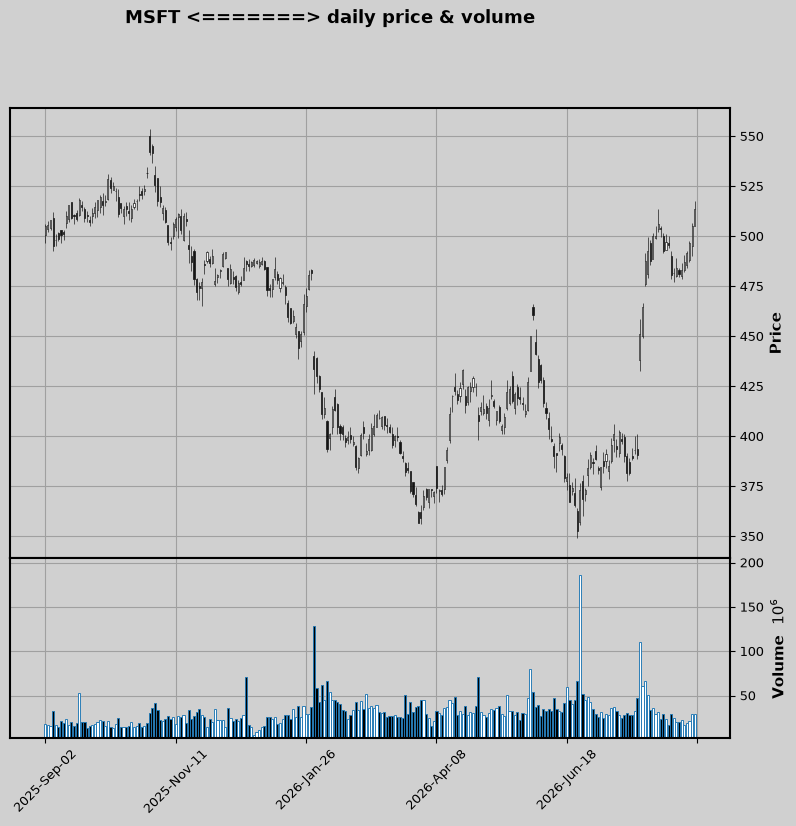

In [60]:
# a plot??
mpf.plot(
    data,
    type = "candle",
    style = style,
    volume = True,
    figsize = (10, 9),
    title = "MSFT <=======> daily price & volume"
)

In [61]:
# simple moving averagess
df = data.copy()

In [62]:
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()


In [63]:
# EMA
df["EMA_20"] = df["Close"].ewm(
    span = 20,
    adjust = False
).mean()

df["EMA_50"] = df["Close"].ewm(
    span = 50,
    adjust = False
).mean()

In [64]:
### ploooots
moving_averages = [
    mpf.make_addplot(df["SMA_20"], color="black", width=1),
    mpf.make_addplot(df["SMA_50"], color="gray", width=1),
    mpf.make_addplot(df["SMA_200"], color="black", width=1.5),
    mpf.make_addplot(df["EMA_20"], color="dimgray", width=1),
    mpf.make_addplot(df["EMA_50"], color="black", width=1)
]

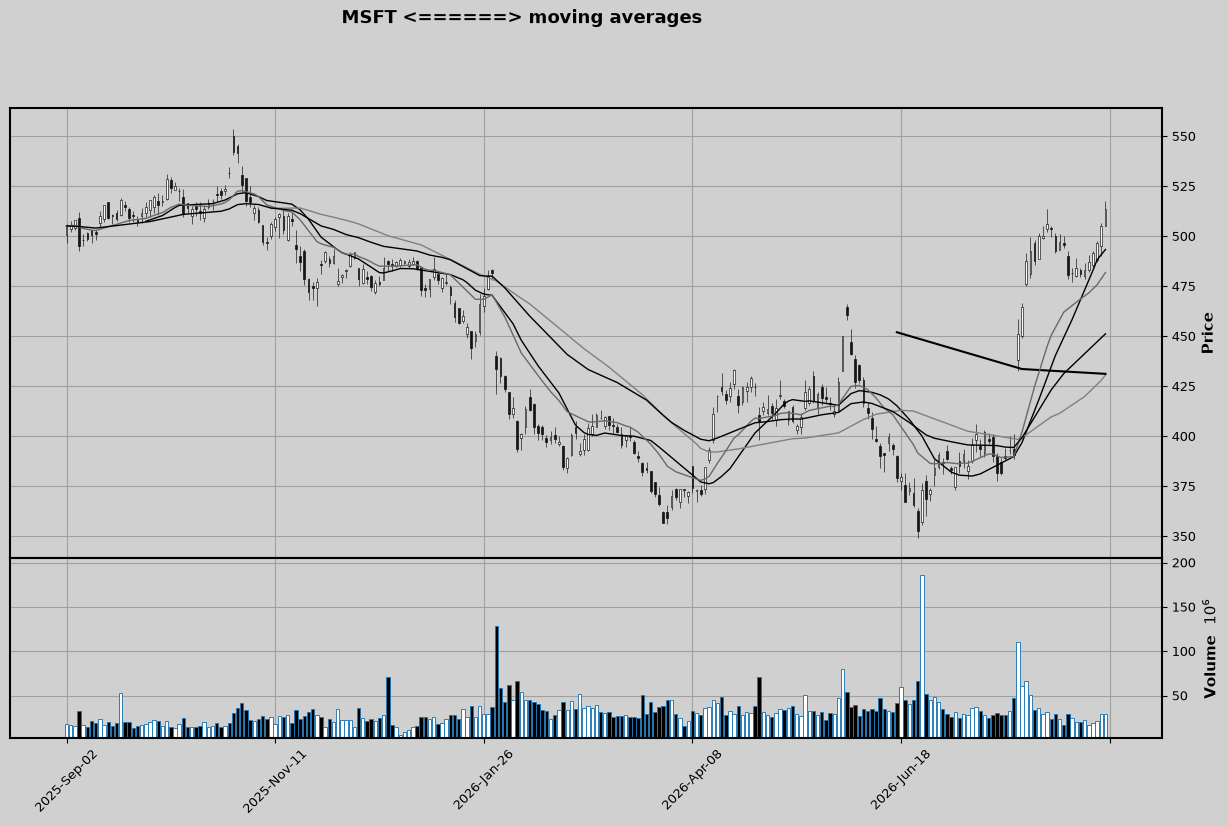

In [65]:
mpf.plot(
    df,
    type = "candle",
    style = style,
    volume = True,
    addplot = moving_averages,
    figsize = (16, 9),
    title = "MSFT <======> moving averages"
)

In [66]:
# bollinger bands
df["BB_Middle"] = df["Close"].rolling(20).mean()

df["BB_Std"] = df["Close"].rolling(20).std()

df["BB_Upper"] = (
    df["BB_Middle"] +
    2 * df["BB_Std"]
)

df["BB_Lower"] = (
    df["BB_Middle"] -
    2 * df["BB_Std"]
)

In [69]:
bollinger = [
    mpf.make_addplot(
        df["BB_Middle"],
        color="red",
        width=1
    ),

    mpf.make_addplot(
        df["BB_Upper"],
        color="green",
        width=1
    ),

    mpf.make_addplot(
        df["BB_Lower"],
        color="green",
        width=1
    )
]

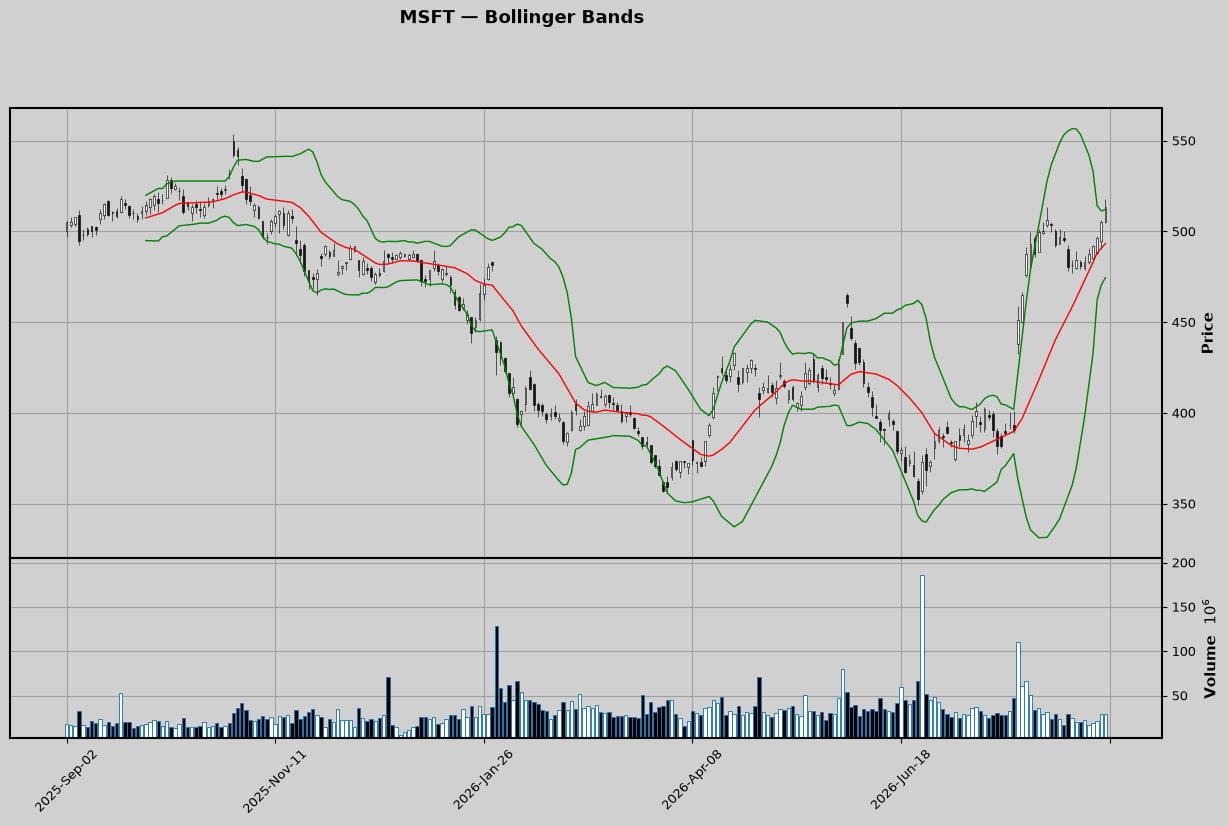

In [70]:
mpf.plot(
    df,
    type="candle",
    style=style,
    volume=True,
    addplot=bollinger,
    figsize=(16, 9),
    title="MSFT — Bollinger Bands"
)

In [71]:
# macd
df["EMA_12"] = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

df["EMA_26"] = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]

df["MACD_Signal"] = df["MACD"].ewm(
    span=9,
    adjust=False
).mean()

df["MACD_Hist"] = (
    df["MACD"] -
    df["MACD_Signal"]
)

In [79]:
macd_plots = [

    mpf.make_addplot(
        df["MACD"],
        panel=1,
        color="black",
        width=1
    ),

    mpf.make_addplot(
        df["MACD_Signal"],
        panel=1,
        color="gray",
        width=1
    ),

    mpf.make_addplot(
        df["MACD_Hist"],
        panel=1,
        type="bar",
        color="black",
        alpha=0.7
    )
]

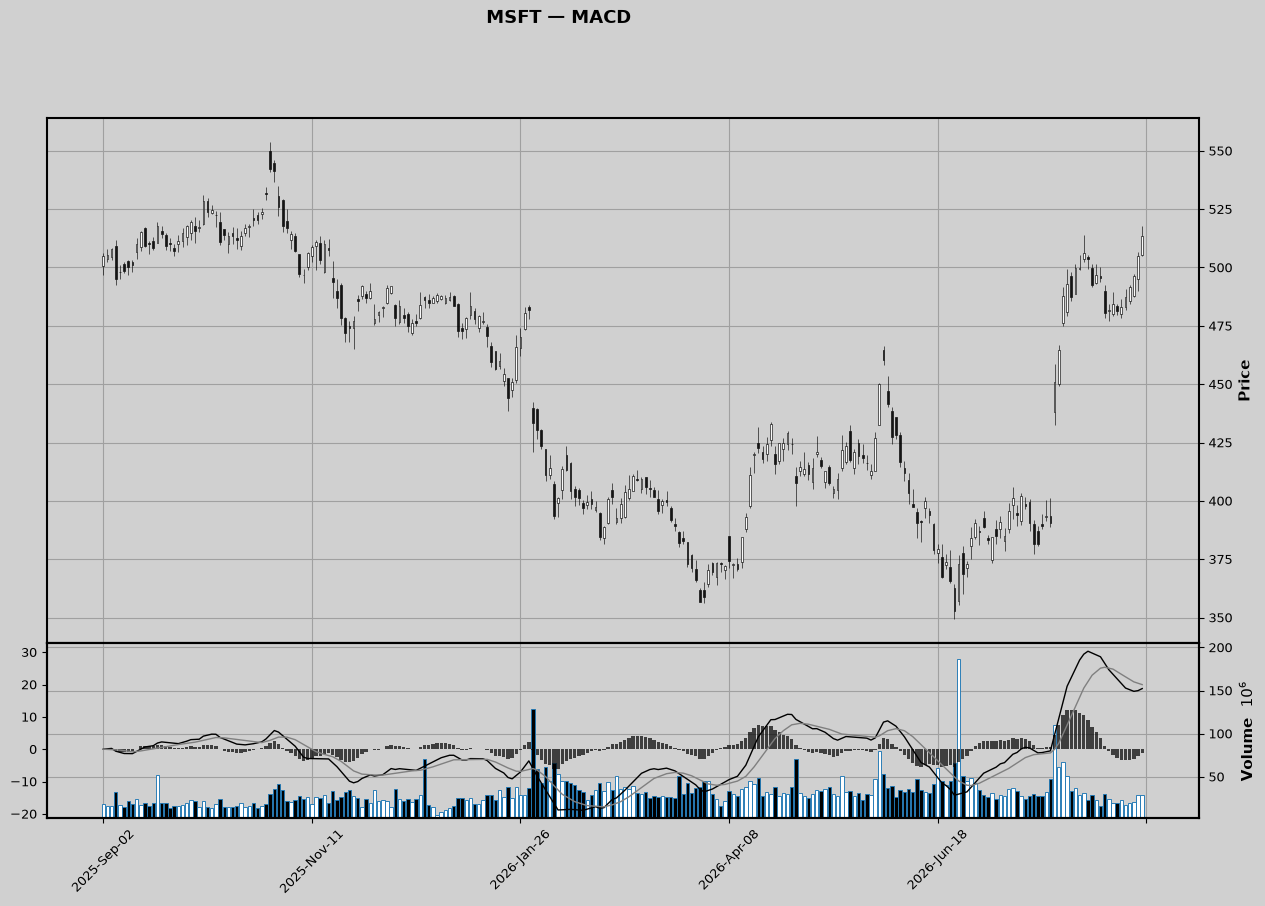

In [80]:
mpf.plot(
    df,
    type="candle",
    style=style,
    volume=True,
    addplot=macd_plots,
    panel_ratios=(6, 2),
    figsize=(16, 10),
    title="MSFT — MACD"
)